In [25]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'bilateral-m1-pcca', 'tools'))
# Simpler if you run the notebook from the repo root:
sys.path.insert(0, 'tools')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import scipy.io
import numpy as np
from load_session import inspect_session, load_session
from trial_epoching import get_trial_start_indices, get_touch_start_indices, get_trial_outcomes, compute_derived    
from plotting_fncs import plot_trial_variable, plot_session_metrics
from input_data_generation import get_neuron_mask, build_spike_count_matrices, prepare_session_for_pcca
from run_save_model import fit_session_pcca, extract_session_metrics, save_session_results#, run_or_load_session

import matplotlib.pyplot as plt
%matplotlib widget


In [3]:
# inspect_session('data/P1.mat')

In [38]:
session_id='U2'
session_data = load_session(f'data/{session_id}.mat')
derived = compute_derived(session_data)

## U7, U8 problem
## U1 only has 17 neurons in LH




In [39]:
### Stimulus and outcome information

print(f' All Unique stimuli: {set(derived["trial_stimuli"])}')
print(f' Rewarded stimuli: {set([derived["trial_stimuli"][i] for i, o in enumerate(derived["trial_outcomes"]) if o in ["hit", "miss"]])}')
print(f' Unrewarded stimuli: {set([derived["trial_stimuli"][i] for i, o in enumerate(derived["trial_outcomes"]) if o in ["false_alarm", "correct_rej"]])}')
print(f' Total hit trials: {sum([1 for o in derived["trial_outcomes"] if o == "hit"])}')
print(f' Total miss trials: {sum([1 for o in derived["trial_outcomes"] if o == "miss"])}')
print(f' Total false alarm trials: {sum([1 for o in derived["trial_outcomes"] if o == "false_alarm"])}')
print(f' Total correct rejection trials: {sum([1 for o in derived["trial_outcomes"] if o == "correct_rej"])}')

 All Unique stimuli: {'rightD+leftC', 'rightC+leftC', 'rightC+leftD', 'leftC', 'rightC', 'leftD', 'rightD', 'rightD+leftD'}
 Rewarded stimuli: {'rightC'}
 Unrewarded stimuli: {'rightD+leftC', 'rightC+leftC', 'rightC+leftD', 'leftC', 'leftD', 'rightD', 'rightD+leftD'}
 Total hit trials: 113
 Total miss trials: 4
 Total false alarm trials: 12
 Total correct rejection trials: 313


In [6]:
### Neuronal data information

print(f'LH neurons: {session_data["n_lh"]}, RH neurons: {session_data["n_rh"]}, Total neurons: {session_data["n_lh"] + session_data["n_rh"]}')

rs = np.sum(session_data['fsrs'] == 1)
fs = np.sum(session_data['fsrs'] == -1)
un = np.sum(session_data['fsrs'] == 0)

print(f"RS: {rs}, FS: {fs}, UN: {un}")

for hemi, mask in [('LH', session_data['loc_lh_mask']), ('RH', session_data['loc_rh_mask'])]:
    fsrs = session_data['fsrs'][mask]
    print(f"{hemi}  RS: {(fsrs==1).sum()}  FS: {(fsrs==-1).sum()}  UN: {(fsrs==0).sum()}")


LH neurons: 100, RH neurons: 98, Total neurons: 198
RS: 184, FS: 6, UN: 8
LH  RS: 97  FS: 1  UN: 2
RH  RS: 87  FS: 5  UN: 6


Hit trials : 113
Touch latency — mean: 0.662 s  median: 0.660 s
Lick latency  — mean: 1.050 s  median: 1.054 s


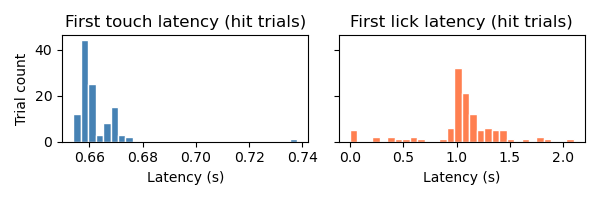

In [15]:
from load_session import TIME_STEP

# ── Reference point: swap between trial start and stimulus onset ──────────
reference_frames = derived['trial_start_indices'].astype(float)   # trial start
# reference_frames = derived['stimulus_onset_frame']              # stimulus onset

# ── Hit trials only ───────────────────────────────────────────────────────
hit_mask = np.array([o == 'hit' for o in derived['trial_outcomes']])
# ── Latencies (seconds) ───────────────────────────────────────────────────
touch_latency_s = (derived['first_touch_frame'][hit_mask] - reference_frames[hit_mask]) * TIME_STEP
lick_latency_s  = (derived['first_lick_frame'][hit_mask]  - reference_frames[hit_mask]) * TIME_STEP

print(f"Hit trials : {hit_mask.sum()}")
print(f"Touch latency — mean: {np.nanmean(touch_latency_s):.3f} s  median: {np.nanmedian(touch_latency_s):.3f} s")
print(f"Lick latency  — mean: {np.nanmean(lick_latency_s):.3f} s  median: {np.nanmedian(lick_latency_s):.3f} s")

fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)

axes[0].hist(touch_latency_s[~np.isnan(touch_latency_s)], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Latency (s)')
axes[0].set_ylabel('Trial count')
axes[0].set_title('First touch latency (hit trials)')

axes[1].hist(lick_latency_s[~np.isnan(lick_latency_s)], bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Latency (s)')
axes[1].set_title('First lick latency (hit trials)')

plt.tight_layout()
plt.show()


In [8]:


# valid_vars = ['piston_frames', 'touch_frames', 'whisker_angle', 'curvature',
#               'phase', 'run_speed', 'hits', 'misses', 'false_alarms',
#               'correct_rejs', 'licks']
# for var_name in valid_vars:
#     if var_name in ['hits', 'misses', 'false_alarms', 'correct_rejs', 'licks']:
#         plot_trial_variable(session_data, session_data['trial_start_indices'], var_name=var_name, trial_idx=1, ylim=(-0.1, 1.1))
#     else:
#         plot_trial_variable(session_data, session_data['trial_start_indices'], var_name=var_name, trial_idx=1)



In [22]:
hit_mask = np.array([o == 'hit' for o in derived['trial_outcomes']])
miss_mask = np.array([o == 'miss' for o in derived['trial_outcomes']])
correct_rej_mask = np.array([o == 'correct_rej' for o in derived['trial_outcomes']])
false_alarm_mask = np.array([o == 'false_alarm' for o in derived['trial_outcomes']])

hit_fast_lick_mask = hit_mask.copy()
hit_fast_lick_mask[hit_mask] = lick_latency_s > 1.0
combined_mask = hit_fast_lick_mask | miss_mask | correct_rej_mask
filtered_trial_indices = np.where(combined_mask)[0]

print(f"Filtered trials: {len(filtered_trial_indices)}")

lh_neuron_mask = get_neuron_mask(session_data, hemisphere='LH', fsrs=[1, -1], min_rate_hz=0.5)
rh_neuron_mask = get_neuron_mask(session_data, hemisphere='RH', fsrs=[1, -1], min_rate_hz=0.5)

# lh_matrix, rh_matrix = build_spike_count_matrices(
#     session_data,
#     trial_indices    = filtered_trial_indices,
#     reference_frames = derived['trial_start_indices'],  # or derived['stimulus_onset_frame']
#     window           = (0.0, 1.0),
#     lh_neuron_mask   = lh_neuron_mask,
#     rh_neuron_mask   = rh_neuron_mask,
# )


bundle = prepare_session_for_pcca(
    session_data     = session_data,
    derived          = derived,
    trial_indices    = filtered_trial_indices,
    window           = (0.0, 0.5),            # 0–500 ms post-stimulus
    lh_neuron_mask   = lh_neuron_mask,
    rh_neuron_mask   = rh_neuron_mask,
)

# quick sanity check
print(f"Trials: {len(bundle['trial_indices'])}")
print(f"LH: {bundle['n_lh']} neurons,  RH: {bundle['n_rh']} neurons")
print(f"Raw LH mean: {bundle['lh_raw'].mean():.3f}")
print(f"Pre LH mean: {bundle['lh'].mean():.6f}")   # should be near zero
print(f"Stimulus conditions: {np.unique(bundle['stimulus_labels'], return_counts=True)}")
# print(f"LH: {lh_neuron_mask.sum()} / {session_data['n_lh']} neurons kept")
# print(f"RH: {rh_neuron_mask.sum()} / {session_data['n_rh']} neurons kept")
# print(f"LH matrix: {lh_matrix.shape},  RH matrix: {rh_matrix.shape}")


Filtered trials: 406
Trials: 406
LH: 98 neurons,  RH: 92 neurons
Raw LH mean: 4.039
Pre LH mean: -0.005206
Stimulus conditions: (array(['go', 'nogo'], dtype=object), array([ 93, 313]))


In [ ]:
model, cv_results = fit_session_pcca(bundle, d_max=6, n_folds=10, rand_seed=42)
metrics, summary = extract_session_metrics(model, session_id=session_id)


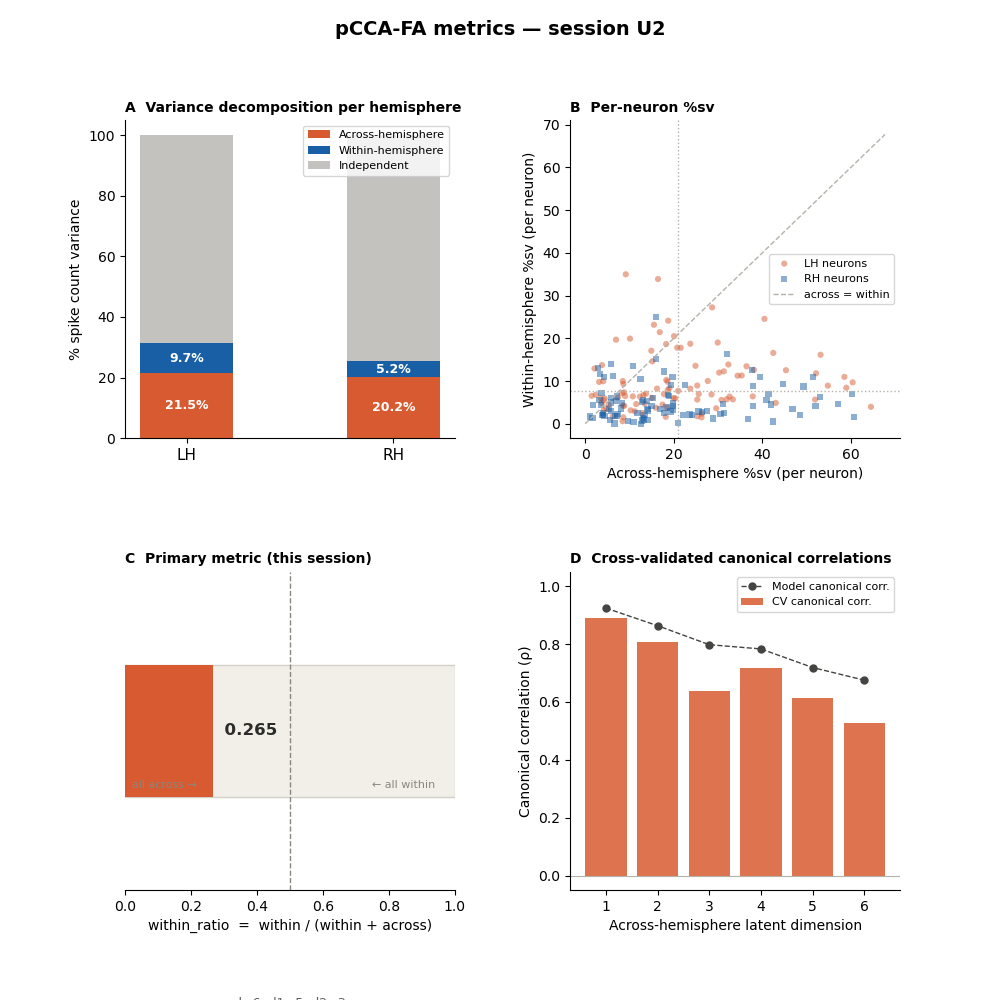

In [42]:
fig = plot_session_metrics(metrics, summary, session_id=session_id)

In [49]:
save_session_results(session_id, model, cv_results, metrics, summary)

Saved → results/U2.joblib  (30.4 KB)


In [52]:
# Call this on your preprocessed matrices
z, LL = model.estep(bundle['lh'], bundle['rh'])

z['z_mu']    # (T, d)   ← across-hemisphere latent variables, one value per trial
z['zx1_mu']  # (T, d1)  ← within-LH latent variables per trial
z['zx2_mu']  # (T, d2)  ← within-RH latent variables per trial
# z_cov, zx1_cov, zx2_cov also available — posterior uncertainty per dimension

array([[-0.85354709, -0.2974316 ,  0.52050742],
       [-0.84877797, -3.84823211, -0.93555062],
       [ 0.29399757,  0.85463899,  1.20935512],
       ...,
       [-1.22567227,  0.68257744, -0.40493348],
       [-1.34876322,  0.61576706, -0.54064571],
       [ 0.09890717,  0.57560287,  0.57766793]])

In [51]:
metrics['psv'].keys()

dict_keys(['psv_W_1', 'psv_W_2', 'psv_L_1', 'psv_L_2', 'avg_psv_W_1', 'avg_psv_W_2', 'avg_psv_L_1', 'avg_psv_L_2', 'ind_var_x1', 'ind_var_x2', 'avg_psv_W_total', 'avg_psv_L_total'])

In [44]:
summary

{'session_id': 'U2',
 'avg_psv_W': 20.886119275158144,
 'avg_psv_L': 7.549135629363718,
 'within_ratio': 0.2654850696683303,
 'avg_psv_W_lh': 21.526637176558324,
 'avg_psv_L_lh': 9.748372842014975,
 'avg_psv_W_rh': 20.203828467144916,
 'avg_psv_L_rh': 5.2064699028438985,
 'within_ratio_lh': 0.31169847223792113,
 'within_ratio_rh': 0.20489605541165434,
 'd': 6,
 'd1': 5,
 'd2': 3}

In [ ]:
# # ── putting it together for one session ───────────────────────────────────────

# def run_session(bundle, session_id=None, d_max=6, n_folds=10, rand_seed=42):
#     """
#     Full Steps 4+5 for one session. Call this per animal.

#     Returns model, cv_results, metrics, summary.
#     """
#     model, cv_results = fit_session_pcca(
#         bundle, d_max=d_max, n_folds=n_folds, rand_seed=rand_seed
#     )
#     metrics, summary = extract_session_metrics(model, session_id=session_id)

#     print(f"\n── Session {session_id} ──────────────────────")
#     print(f"  across %sv : {summary['avg_psv_W']:.2f}%")
#     print(f"  within %sv : {summary['avg_psv_L']:.2f}%")
#     print(f"  within_ratio (primary): {summary['within_ratio']:.4f}")

#     return model, cv_results, metrics, summary

# from scipy.stats import mannwhitneyu
# import pandas as pd

# # collect per-session summaries into a dataframe
# # run_session() once per animal, label each with training group
# records = []
# for session_id, bundle, group in session_list:   # group = 'unilateral' or 'bilateral'
#     _, _, _, summary = run_session(bundle, session_id=session_id)
#     summary['group'] = group
#     records.append(summary)

# df = pd.DataFrame(records)

# # group-level comparison on the primary metric
# uni = df.loc[df['group'] == 'unilateral', 'within_ratio']
# bil = df.loc[df['group'] == 'bilateral',  'within_ratio']

# stat, p = mannwhitneyu(uni, bil, alternative='greater')  # H1: unilateral > bilateral

# print(f"\nMann-Whitney U:  U={stat:.1f},  p={p:.4f}")
# print(f"Unilateral within_ratio:  mean={uni.mean():.4f}, n={len(uni)}")
# print(f"Bilateral  within_ratio:  mean={bil.mean():.4f}, n={len(bil)}")

NameError: name 'session_list' is not defined